# Seoul Bike Sharing Demand - Corrected Pre-Training Notebook

This notebook prepares the Seoul hourly bike sharing dataset for regression benchmark models. It stops before model training.

Working principles used here:

- First understand the dataset and the business meaning of each column.
- Keep the target question explicit: predict bike demand during functioning service hours.
- Use chronological splitting because the rows are hourly time-ordered observations.
- Fit learned preprocessing steps only on the training period.
- Prefer simple, explainable preprocessing unless the data clearly asks for more.

Sources checked for the workflow:

- UCI dataset page: https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand
- scikit-learn common pitfalls and leakage guidance: https://scikit-learn.org/stable/common_pitfalls.html
- scikit-learn Pipeline and ColumnTransformer guidance: https://scikit-learn.org/stable/modules/compose.html
- scikit-learn TimeSeriesSplit guidance: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("seoul+bike+sharing+demand") / "SeoulBikeData.csv"
TARGET = "rented_bike_count"
RANDOM_STATE = 42

print(f"Dataset path exists: {DATA_PATH.exists()}")
print(f"Dataset path: {DATA_PATH}")


Dataset path exists: True
Dataset path: seoul+bike+sharing+demand\SeoulBikeData.csv


## 1. Load The Raw Data

The CSV header contains special characters in temperature columns, so the file is read with `cp1252`, which matches this local file. At this point, I only inspect the raw shape, schema, and a few rows.


In [2]:
raw = pd.read_csv(DATA_PATH, encoding="cp1252")

print(f"Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]:,} columns")
display(raw.head(3))

schema = pd.DataFrame({
    "column": raw.columns,
    "dtype": raw.dtypes.astype(str).values,
    "missing": raw.isna().sum().values,
    "unique_values": raw.nunique().values,
})
display(schema)


Raw shape: 8,760 rows x 14 columns


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes


,column,dtype,missing,unique_values
0,Date,object,0,365
1,Rented Bike Count,int64,0,2166
2,Hour,int64,0,24
3,Temperature(°C),float64,0,546
4,Humidity(%),int64,0,90
5,Wind speed (m/s),float64,0,65
6,Visibility (10m),int64,0,1789
7,Dew point temperature(°C),float64,0,556
8,Solar Radiation (MJ/m2),float64,0,345
9,Rainfall(mm),float64,0,61


## 2. Clean Names And Build The Hourly Timestamp

The original columns are renamed once into stable snake_case names. The date is day-first, then `date + hour` gives the real hourly timestamp. This timestamp is used for chronology checks and later for time features.


In [3]:
rename_map = {
    "Date": "date",
    "Rented Bike Count": "rented_bike_count",
    "Hour": "hour",
    "Temperature(°C)": "temperature_c",
    "Humidity(%)": "humidity_percent",
    "Wind speed (m/s)": "wind_speed_m_s",
    "Visibility (10m)": "visibility_10m",
    "Dew point temperature(°C)": "dew_point_temperature_c",
    "Solar Radiation (MJ/m2)": "solar_radiation_mj_m2",
    "Rainfall(mm)": "rainfall_mm",
    "Snowfall (cm)": "snowfall_cm",
    "Seasons": "season",
    "Holiday": "holiday",
    "Functioning Day": "functioning_day",
}

df = raw.rename(columns=rename_map).copy()
df["date"] = pd.to_datetime(df["date"], dayfirst=True)
df["datetime"] = df["date"] + pd.to_timedelta(df["hour"], unit="h")
df = df.sort_values("datetime").reset_index(drop=True)

ordered_columns = ["datetime", "date", "hour", TARGET,
                   "temperature_c", "humidity_percent", "wind_speed_m_s", "visibility_10m",
                   "dew_point_temperature_c", "solar_radiation_mj_m2", "rainfall_mm", "snowfall_cm",
                   "season", "holiday", "functioning_day"]
df = df[ordered_columns]

hour_gap = df["datetime"].diff().dt.total_seconds().div(3600)

time_checks = pd.Series({
    "rows": len(df),
    "start": df["datetime"].min(),
    "end": df["datetime"].max(),
    "duplicate_rows": int(df.duplicated().sum()),
    "duplicate_datetimes": int(df["datetime"].duplicated().sum()),
    "missing_cells": int(df.isna().sum().sum()),
    "non_1_hour_gaps_after_first_row": int(hour_gap.dropna().ne(1).sum()),
})

display(time_checks.to_frame("value"))
display(hour_gap.value_counts(dropna=False).rename_axis("hour_gap").reset_index(name="rows"))


,value
rows,8760
start,2017-12-01 00:00:00
end,2018-11-30 23:00:00
duplicate_rows,0
duplicate_datetimes,0
missing_cells,0
non_1_hour_gaps_after_first_row,0


,hour_gap,rows
0,1.0,8759
1,NaN,1


## 3. First Dataset Profile

This step checks the basic behavior of the numeric and categorical columns before any modeling decision. It is data understanding, not feature selection.


In [4]:
numeric_columns = [
    TARGET, "hour", "temperature_c", "humidity_percent", "wind_speed_m_s", "visibility_10m",
    "dew_point_temperature_c", "solar_radiation_mj_m2", "rainfall_mm", "snowfall_cm",
]

numeric_profile = df[numeric_columns].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T.round(2)
display(numeric_profile)

zero_profile = pd.DataFrame({
    "zero_rows": [(df[col] == 0).sum() for col in numeric_columns],
    "zero_share": [(df[col] == 0).mean() for col in numeric_columns],
}, index=numeric_columns)
display(zero_profile.round(4))


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
rented_bike_count,8760.0,704.60,645.00,0.0,0.00,22.0,191.00,504.50,1065.25,2043.00,2526.23,3556.00
hour,8760.0,11.50,6.92,0.0,0.00,1.0,5.75,11.50,17.25,22.00,23.00,23.00
temperature_c,8760.0,12.88,11.94,-17.8,-12.74,-7.1,3.50,13.70,22.50,30.70,35.10,39.40
humidity_percent,8760.0,58.23,20.36,0.0,17.00,27.0,42.00,57.00,74.00,94.00,97.00,98.00
wind_speed_m_s,8760.0,1.72,1.04,0.0,0.10,0.4,0.90,1.50,2.30,3.70,4.70,7.40
visibility_10m,8760.0,1436.83,608.30,27.0,173.00,300.0,940.00,1698.00,2000.00,2000.00,2000.00,2000.00
dew_point_temperature_c,8760.0,4.07,13.06,-30.6,-24.80,-19.5,-4.70,5.10,14.80,22.40,24.70,27.20
solar_radiation_mj_m2,8760.0,0.57,0.87,0.0,0.00,0.0,0.00,0.01,0.93,2.56,3.17,3.52
rainfall_mm,8760.0,0.15,1.13,0.0,0.00,0.0,0.00,0.00,0.00,0.40,4.00,35.00
snowfall_cm,8760.0,0.08,0.44,0.0,0.00,0.0,0.00,0.00,0.00,0.20,2.50,8.80


,zero_rows,zero_share
rented_bike_count,295,0.0337
hour,365,0.0417
temperature_c,21,0.0024
humidity_percent,17,0.0019
wind_speed_m_s,74,0.0084
visibility_10m,0,0.0000
dew_point_temperature_c,60,0.0068
solar_radiation_mj_m2,4300,0.4909
rainfall_mm,8232,0.9397
snowfall_cm,8317,0.9494


In [5]:
for column in ["season", "holiday", "functioning_day"]:
    counts = df[column].value_counts().rename_axis(column).reset_index(name="rows")
    counts["share"] = counts["rows"] / len(df)
    print(f"\n{column}")
    display(counts)



season


,season,rows,share
0,Spring,2208,0.252055
1,Summer,2208,0.252055
2,Autumn,2184,0.249315
3,Winter,2160,0.246575



holiday


,holiday,rows,share
0,No Holiday,8328,0.950685
1,Holiday,432,0.049315



functioning_day


,functioning_day,rows,share
0,Yes,8465,0.966324
1,No,295,0.033676


## 4. Define The Modeling Scope

`Functioning Day` is not an ordinary weather or calendar feature. It marks whether the bike service was operating. In this data, every non-functioning hour has exactly zero rented bikes, while every functioning hour has positive demand.

For a practical demand benchmark, I model demand only when the service is functioning. If a company needs all-hour predictions, the production system should handle operation status separately: return zero for closed hours, and use the demand model for open hours.


In [6]:
status_table = pd.crosstab(df["functioning_day"], df[TARGET].eq(0))
status_table = status_table.rename(columns={False: "positive_target_rows", True: "zero_target_rows"})
status_table["total_rows"] = status_table.sum(axis=1)
display(status_table)

model_df = df[df["functioning_day"].eq("Yes")].drop(columns=["functioning_day"]).reset_index(drop=True)

print(f"Rows before scope filter: {len(df):,}")
print(f"Rows kept for functioning-hour demand: {len(model_df):,}")
print(f"Rows removed as service-closed structural zeros: {len(df) - len(model_df):,}")
print(f"Zero target rows after filtering: {(model_df[TARGET] == 0).sum():,}")


rented_bike_count,positive_target_rows,zero_target_rows,total_rows
functioning_day,,,
No,0,295,295
Yes,8465,0,8465


Rows before scope filter: 8,760
Rows kept for functioning-hour demand: 8,465
Rows removed as service-closed structural zeros: 295
Zero target rows after filtering: 0


## 5. Weather Quality Check

The official dataset reports no missing values, but absence of missing values is not the same as absence of bad values. There are 17 rows where humidity is exactly zero. For these rows, temperature and dew point imply realistic non-zero humidity, so treating zero as a real measurement would be misleading.

Correction used: add a flag, replace only those impossible zero humidity values with missing, then let the train-only imputer handle them later.


In [7]:
def relative_humidity_from_temp_dewpoint(temp_c, dewpoint_c):
    """Approximate relative humidity from temperature and dew point in Celsius."""
    a, b = 17.625, 243.04
    return 100 * np.exp((a * dewpoint_c / (b + dewpoint_c)) - (a * temp_c / (b + temp_c)))

model_df["rh_estimated_from_dewpoint"] = relative_humidity_from_temp_dewpoint(
    model_df["temperature_c"], model_df["dew_point_temperature_c"]
).clip(0, 100)
model_df["weather_consistency_error"] = (model_df["humidity_percent"] - model_df["rh_estimated_from_dewpoint"]).abs()
model_df["weather_consistency_flag"] = model_df["weather_consistency_error"].gt(5).astype("int8")

humidity_zero_mask = model_df["humidity_percent"].eq(0)
humidity_zero_review = model_df.loc[
    humidity_zero_mask,
    ["datetime", "temperature_c", "humidity_percent", "dew_point_temperature_c", "rh_estimated_from_dewpoint", TARGET],
].copy()

print(f"Humidity exactly zero rows: {humidity_zero_mask.sum():,}")
print(f"Rows with humidity/dew-point consistency error above 5 percentage points: {model_df['weather_consistency_flag'].sum():,}")
display(humidity_zero_review.round(2))

model_df["humidity_was_zero"] = humidity_zero_mask.astype("int8")
model_df.loc[humidity_zero_mask, "humidity_percent"] = np.nan


Humidity exactly zero rows: 17
Rows with humidity/dew-point consistency error above 5 percentage points: 27


,datetime,temperature_c,humidity_percent,dew_point_temperature_c,rh_estimated_from_dewpoint,rented_bike_count
4015,2018-05-19 07:00:00,11.4,0,4.5,62.55,436
4058,2018-05-21 02:00:00,13.9,0,-2.1,33.05,262
4059,2018-05-21 03:00:00,13.0,0,-2.5,34.03,165
4060,2018-05-21 04:00:00,12.4,0,-3.4,33.10,113
4061,2018-05-21 05:00:00,11.9,0,-2.7,36.03,200
4062,2018-05-21 06:00:00,11.4,0,-2.0,39.22,467
4063,2018-05-21 07:00:00,12.3,0,-2.7,35.10,1135
4083,2018-05-22 03:00:00,15.5,0,10.4,71.65,406
4084,2018-05-22 04:00:00,15.6,0,10.5,71.67,248
4085,2018-05-22 05:00:00,15.7,0,10.6,71.69,182


## 6. Row-Wise Feature Engineering

These features use only information available in the same row: timestamp, weather, and calendar labels. They are safe to create before splitting because they do not learn from the full dataset.

Rain and snow are highly zero-heavy, so I keep a simple presence flag and a `log1p` amount. This keeps the signal understandable and avoids letting a few heavy precipitation values dominate linear models.


In [8]:
model_df["dayofweek"] = model_df["datetime"].dt.dayofweek
model_df["month"] = model_df["datetime"].dt.month
model_df["month_sin"] = np.sin(2 * np.pi * model_df["month"] / 12)
model_df["month_cos"] = np.cos(2 * np.pi * model_df["month"] / 12)

model_df["rain_present"] = model_df["rainfall_mm"].gt(0).astype("int8")
model_df["snow_present"] = model_df["snowfall_cm"].gt(0).astype("int8")
model_df["sunlight_present"] = model_df["solar_radiation_mj_m2"].gt(0).astype("int8")
model_df["rainfall_log1p"] = np.log1p(model_df["rainfall_mm"])
model_df["snowfall_log1p"] = np.log1p(model_df["snowfall_cm"])

feature_preview_columns = [
    "datetime", "hour", "dayofweek", "month", "month_sin", "month_cos",
    "rainfall_mm", "rain_present", "rainfall_log1p", "snowfall_cm", "snow_present", "snowfall_log1p",
    "humidity_percent", "humidity_was_zero", "weather_consistency_flag",
]
display(model_df[feature_preview_columns].head(8))


,datetime,hour,dayofweek,month,month_sin,month_cos,rainfall_mm,rain_present,rainfall_log1p,snowfall_cm,snow_present,snowfall_log1p,humidity_percent,humidity_was_zero,weather_consistency_flag
0,2017-12-01 00:00:00,0,4,12,-2.449294e-16,1.0,0.0,0,0.0,0.0,0,0.0,37.0,0,0
1,2017-12-01 01:00:00,1,4,12,-2.449294e-16,1.0,0.0,0,0.0,0.0,0,0.0,38.0,0,0
2,2017-12-01 02:00:00,2,4,12,-2.449294e-16,1.0,0.0,0,0.0,0.0,0,0.0,39.0,0,0
3,2017-12-01 03:00:00,3,4,12,-2.449294e-16,1.0,0.0,0,0.0,0.0,0,0.0,40.0,0,0
4,2017-12-01 04:00:00,4,4,12,-2.449294e-16,1.0,0.0,0,0.0,0.0,0,0.0,36.0,0,0
5,2017-12-01 05:00:00,5,4,12,-2.449294e-16,1.0,0.0,0,0.0,0.0,0,0.0,37.0,0,0
6,2017-12-01 06:00:00,6,4,12,-2.449294e-16,1.0,0.0,0,0.0,0.0,0,0.0,35.0,0,0
7,2017-12-01 07:00:00,7,4,12,-2.449294e-16,1.0,0.0,0,0.0,0.0,0,0.0,38.0,0,0


## 7. Chronological Train/Test Split

The rows are hourly observations from the past into the future, so a random split would mix future observations into training. The holdout below uses the first 80% of functioning-hour rows for training and the final 20% for testing.


In [9]:
split_index = int(len(model_df) * 0.80)
train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

split_summary = pd.DataFrame({
    "rows": [len(train_df), len(test_df)],
    "share": [len(train_df) / len(model_df), len(test_df) / len(model_df)],
    "start": [train_df["datetime"].min(), test_df["datetime"].min()],
    "end": [train_df["datetime"].max(), test_df["datetime"].max()],
    "target_mean": [train_df[TARGET].mean(), test_df[TARGET].mean()],
    "target_median": [train_df[TARGET].median(), test_df[TARGET].median()],
}, index=["train", "test"])

display(split_summary.round({"share": 3, "target_mean": 1, "target_median": 1}))
print(f"Chronological holdout valid: {train_df['datetime'].max() < test_df['datetime'].min()}")
print(f"Train seasons: {sorted(train_df['season'].unique())}")
print(f"Test seasons: {sorted(test_df['season'].unique())}")


,rows,share,start,end,target_mean,target_median
train,6772,0.8,2017-12-01 00:00:00,2018-09-11 03:00:00,687.5,444.0
test,1693,0.2,2018-09-11 04:00:00,2018-11-30 23:00:00,895.6,835.0


Chronological holdout valid: True
Train seasons: ['Autumn', 'Spring', 'Summer', 'Winter']
Test seasons: ['Autumn']


## 8. Training-Only EDA For Modeling Decisions

From here, target-dependent EDA uses the training period only. This prevents future test behavior from influencing preprocessing or model choices.


Training target skew: 1.28


,rented_bike_count
count,6772.00
mean,687.55
std,646.00
min,2.00
1%,15.71
5%,45.00
25%,194.00
50%,444.00
75%,1027.00
95%,2066.90


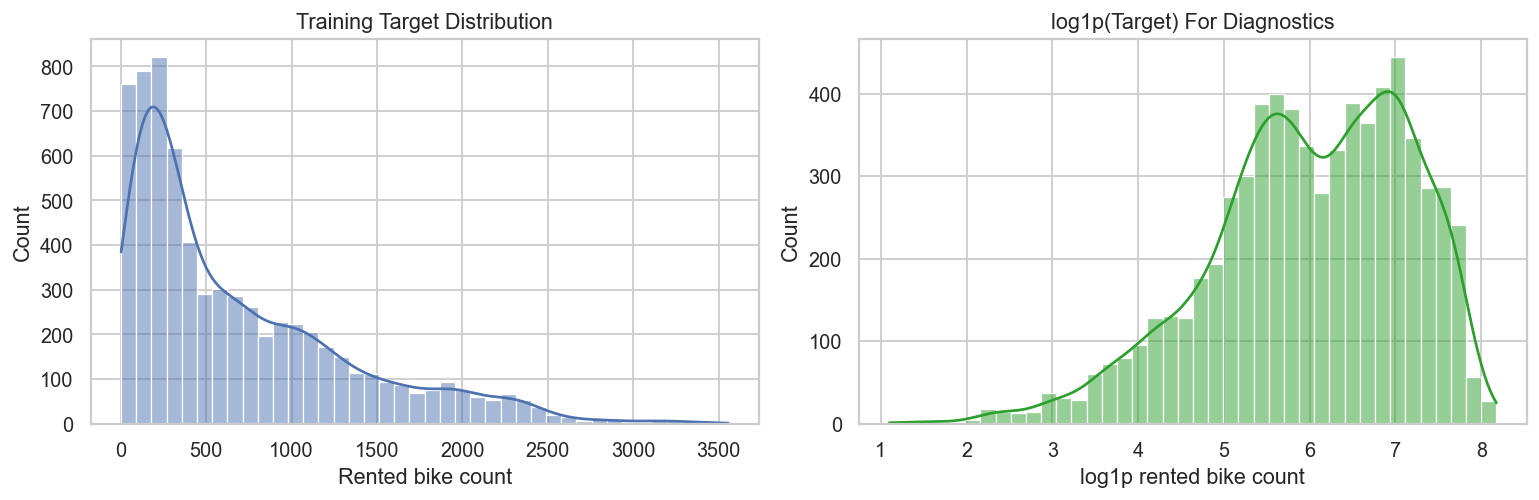

In [10]:
target_summary = train_df[TARGET].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2)
print(f"Training target skew: {train_df[TARGET].skew():.2f}")
display(target_summary.to_frame("rented_bike_count"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_df[TARGET], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Training Target Distribution")
axes[0].set_xlabel("Rented bike count")

sns.histplot(np.log1p(train_df[TARGET]), bins=40, kde=True, ax=axes[1], color="tab:green")
axes[1].set_title("log1p(Target) For Diagnostics")
axes[1].set_xlabel("log1p rented bike count")
plt.tight_layout()
plt.show()


,rows,mean,median
month,,,
1,744,201.6,181.5
2,672,225.9,195.0
3,744,511.6,460.0
4,696,753.2,681.0
5,720,982.1,933.5
6,720,1245.7,1144.5
7,744,987.2,829.5
8,744,876.2,732.5
9,244,1122.0,1044.0


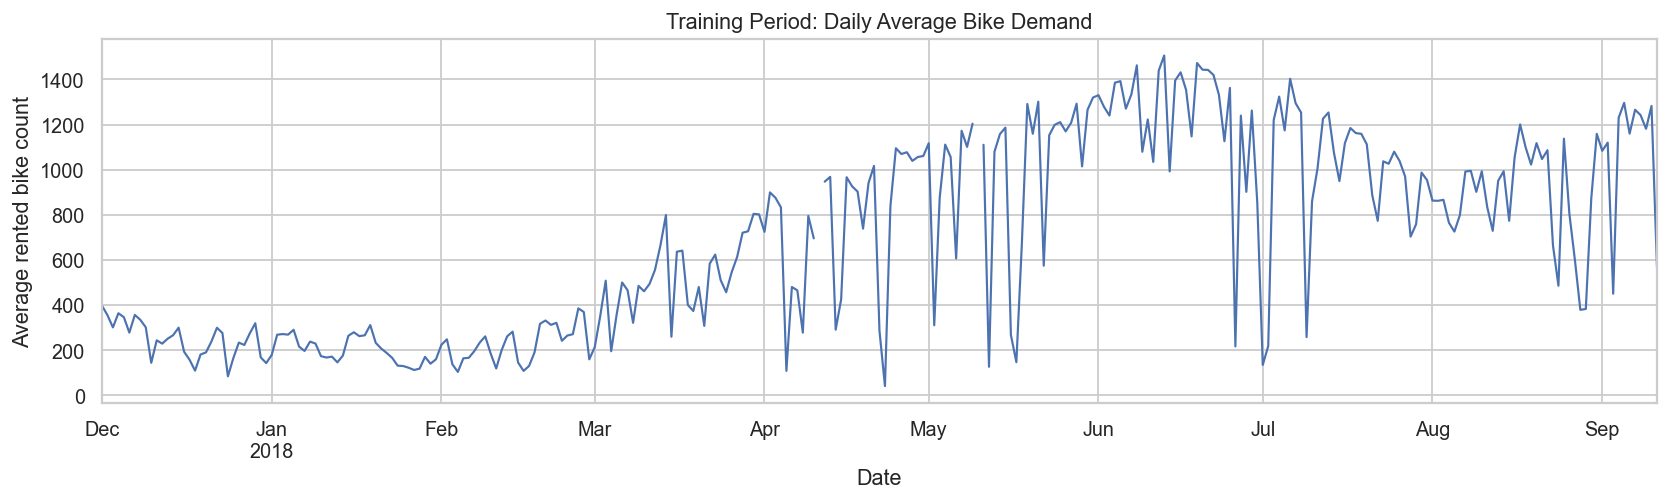

In [11]:
daily_demand = train_df.set_index("datetime")[TARGET].resample("D").mean()

plt.figure(figsize=(13, 4))
daily_demand.plot(linewidth=1.2)
plt.title("Training Period: Daily Average Bike Demand")
plt.xlabel("Date")
plt.ylabel("Average rented bike count")
plt.tight_layout()
plt.show()

monthly_profile = train_df.groupby("month")[TARGET].agg(rows="count", mean="mean", median="median").round(1)
display(monthly_profile)


,rows,mean,median
hour,,,
0,283,533.7,466.0
1,283,420.8,345.0
2,283,301.3,243.0
3,283,202.7,164.0
4,282,131.8,104.5
5,282,141.8,106.0
6,282,288.4,224.5
7,282,593.5,403.0
8,282,983.7,708.0


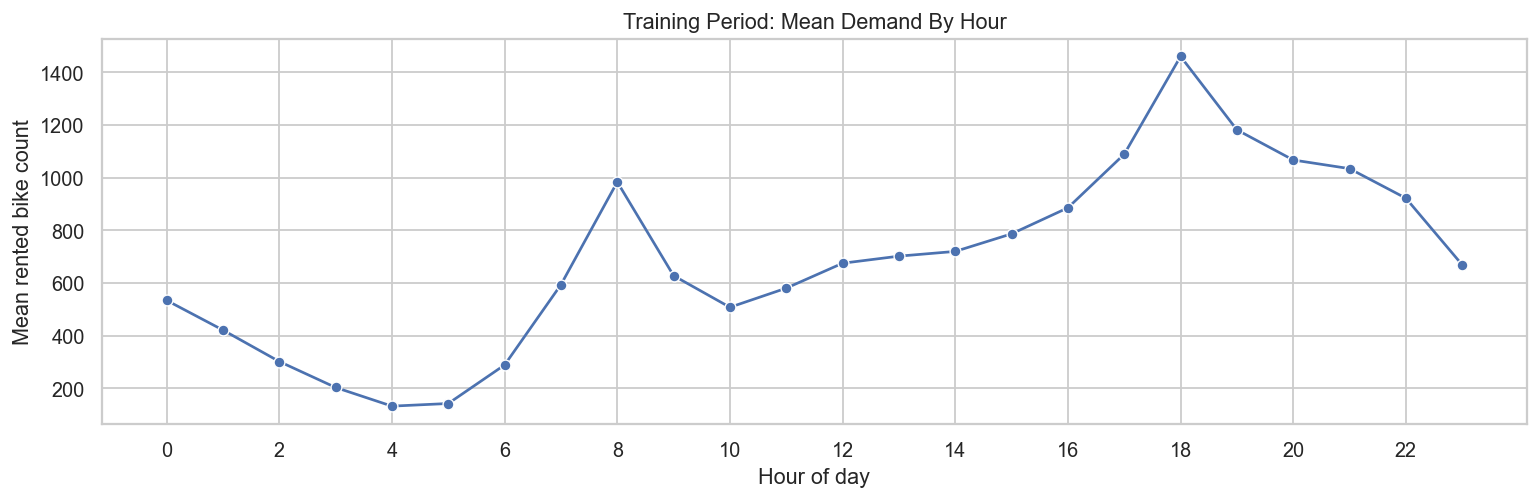

In [12]:
hour_profile = train_df.groupby("hour")[TARGET].agg(rows="count", mean="mean", median="median").round(1)
display(hour_profile)

plt.figure(figsize=(12, 4))
sns.lineplot(data=hour_profile.reset_index(), x="hour", y="mean", marker="o")
plt.title("Training Period: Mean Demand By Hour")
plt.xlabel("Hour of day")
plt.ylabel("Mean rented bike count")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()


,rows,mean,median
season,,,
Autumn,244,1122.0,1044.0
Summer,2208,1034.1,905.5
Spring,2160,746.3,599.0
Winter,2160,225.5,203.0


,rows,mean,median
holiday,,,
Holiday,312,400.2,194.5
No Holiday,6460,701.4,467.0


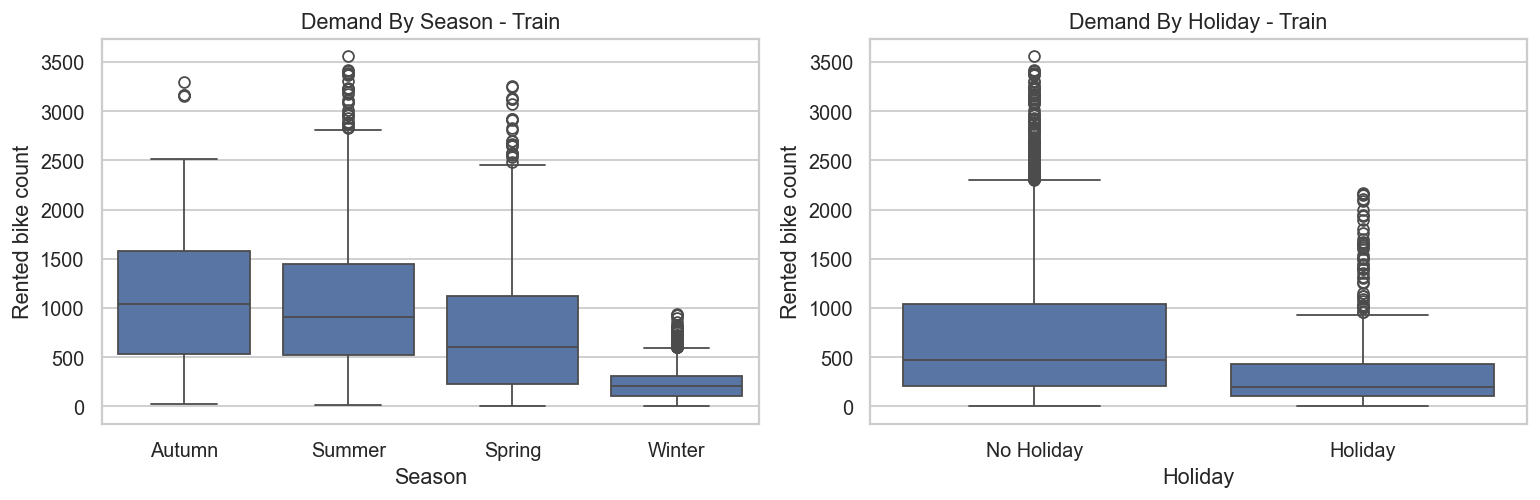

In [13]:
season_profile = train_df.groupby("season", observed=True)[TARGET].agg(rows="count", mean="mean", median="median").round(1).sort_values("mean", ascending=False)
holiday_profile = train_df.groupby("holiday", observed=True)[TARGET].agg(rows="count", mean="mean", median="median").round(1)

display(season_profile)
display(holiday_profile)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=train_df, x="season", y=TARGET, order=season_profile.index, ax=axes[0])
axes[0].set_title("Demand By Season - Train")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Rented bike count")

sns.boxplot(data=train_df, x="holiday", y=TARGET, ax=axes[1])
axes[1].set_title("Demand By Holiday - Train")
axes[1].set_xlabel("Holiday")
axes[1].set_ylabel("Rented bike count")
plt.tight_layout()
plt.show()


,feature,group,rows,mean
0,temperature_c,<=0,1432,193.2
1,temperature_c,0-10,1474,331.2
2,temperature_c,10-20,1282,777.7
3,temperature_c,20-30,2072,1123.3
4,temperature_c,>30,512,1106.4
5,rainfall_mm,no rain,6332,723.5
6,rainfall_mm,0-1,238,221.5
7,rainfall_mm,1-5,151,118.4
8,rainfall_mm,5-15,40,75.5
9,rainfall_mm,15+,11,105.5


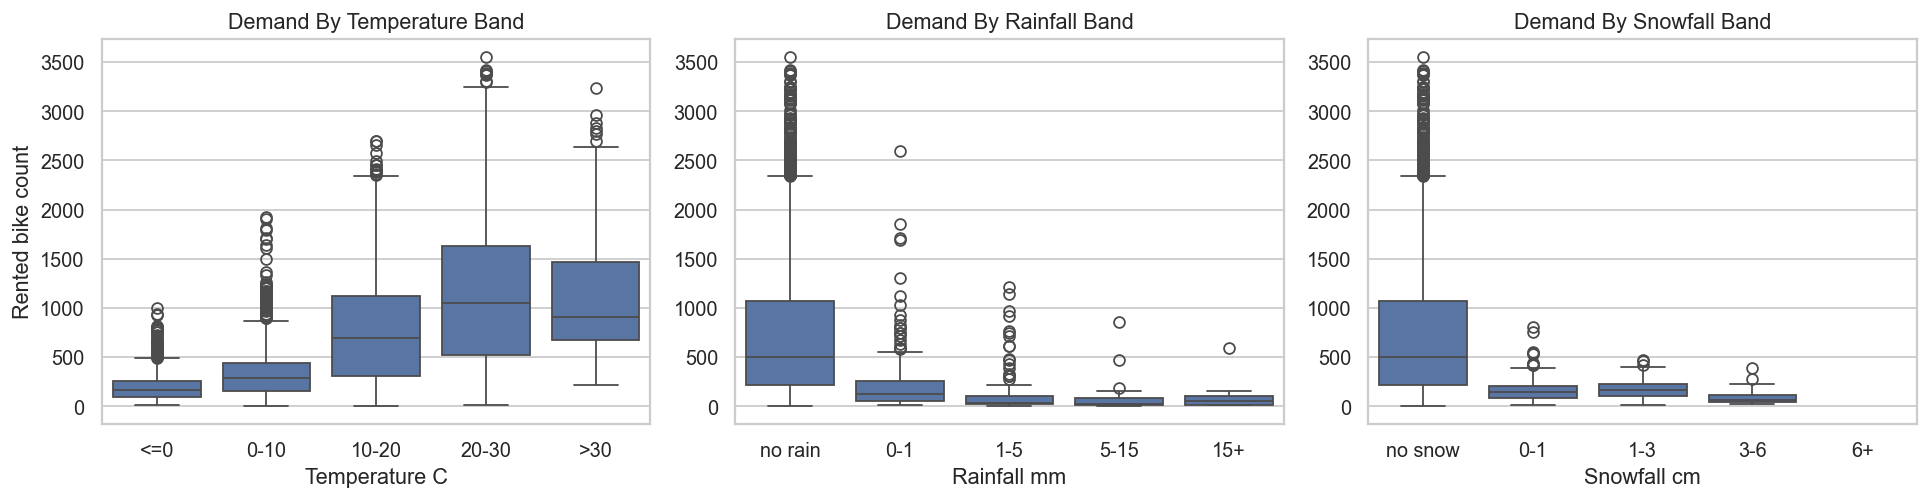

In [14]:
temp_bins = pd.cut(train_df["temperature_c"], bins=[-30, 0, 10, 20, 30, 45], labels=["<=0", "0-10", "10-20", "20-30", ">30"])
rain_bins = pd.cut(train_df["rainfall_mm"], bins=[-0.01, 0, 1, 5, 15, np.inf], labels=["no rain", "0-1", "1-5", "5-15", "15+"])
snow_bins = pd.cut(train_df["snowfall_cm"], bins=[-0.01, 0, 1, 3, 6, np.inf], labels=["no snow", "0-1", "1-3", "3-6", "6+"])

weather_summary = pd.concat([
    train_df.assign(group=temp_bins).groupby("group", observed=True)[TARGET].agg(rows="count", mean="mean").assign(feature="temperature_c"),
    train_df.assign(group=rain_bins).groupby("group", observed=True)[TARGET].agg(rows="count", mean="mean").assign(feature="rainfall_mm"),
    train_df.assign(group=snow_bins).groupby("group", observed=True)[TARGET].agg(rows="count", mean="mean").assign(feature="snowfall_cm"),
]).reset_index()[["feature", "group", "rows", "mean"]]

display(weather_summary.round({"mean": 1}))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(x=temp_bins, y=train_df[TARGET], ax=axes[0])
axes[0].set_title("Demand By Temperature Band")
axes[0].set_xlabel("Temperature C")
axes[0].set_ylabel("Rented bike count")

sns.boxplot(x=rain_bins, y=train_df[TARGET], ax=axes[1])
axes[1].set_title("Demand By Rainfall Band")
axes[1].set_xlabel("Rainfall mm")
axes[1].set_ylabel("")

sns.boxplot(x=snow_bins, y=train_df[TARGET], ax=axes[2])
axes[2].set_title("Demand By Snowfall Band")
axes[2].set_xlabel("Snowfall cm")
axes[2].set_ylabel("")
plt.tight_layout()
plt.show()


,corr_with_target
temperature_c,0.596
month_cos,-0.529
dew_point_temperature_c,0.452
solar_radiation_mj_m2,0.288
month_sin,-0.273
visibility_10m,0.187
snowfall_log1p,-0.180
rainfall_log1p,-0.179
humidity_percent,-0.161
wind_speed_m_s,0.134


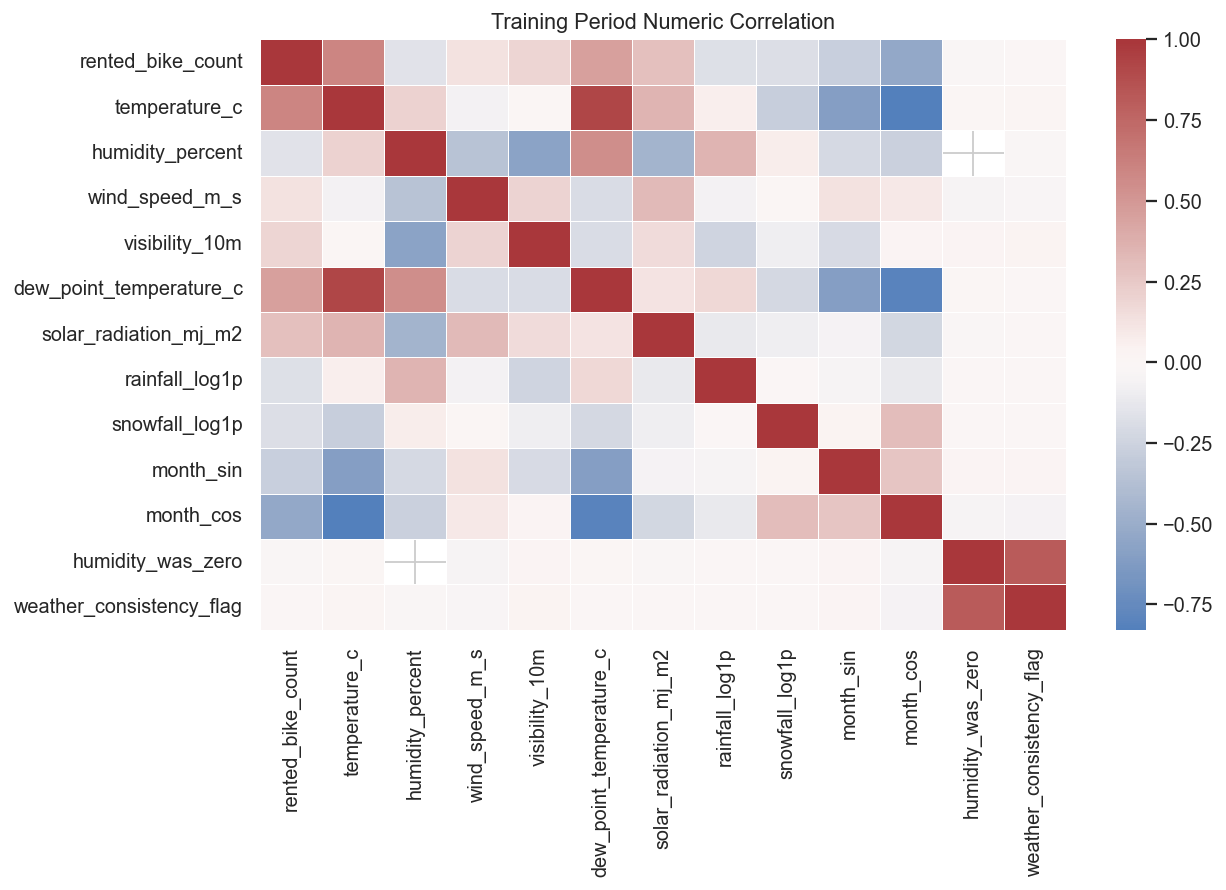

In [15]:
corr_columns = [
    TARGET, "temperature_c", "humidity_percent", "wind_speed_m_s", "visibility_10m",
    "dew_point_temperature_c", "solar_radiation_mj_m2", "rainfall_log1p", "snowfall_log1p",
    "month_sin", "month_cos", "humidity_was_zero", "weather_consistency_flag",
]

corr = train_df[corr_columns].corr(numeric_only=True)
target_corr = corr[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False).round(3)
display(target_corr.to_frame("corr_with_target"))

plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap="vlag", center=0, linewidths=0.3)
plt.title("Training Period Numeric Correlation")
plt.tight_layout()
plt.show()


## 9. Build Feature Matrix

The target and timestamp are removed from `X`. The timestamp was useful for validation and feature engineering, but a plain datetime object should not be passed directly into benchmark regression models.


In [16]:
categorical_features = ["hour", "dayofweek", "season", "holiday"]

numeric_features = [
    "temperature_c", "humidity_percent", "wind_speed_m_s", "visibility_10m",
    "dew_point_temperature_c", "solar_radiation_mj_m2",
    "rainfall_log1p", "snowfall_log1p",
    "rain_present", "snow_present", "sunlight_present",
    "month_sin", "month_cos", "humidity_was_zero", "weather_consistency_flag",
]

model_features = numeric_features + categorical_features

X_train = train_df[model_features].copy()
y_train = train_df[TARGET].copy()
X_test = test_df[model_features].copy()
y_test = test_df[TARGET].copy()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print("\nNumeric features:")
print(numeric_features)
print("\nCategorical features:")
print(categorical_features)

display(X_train.head(3))


X_train shape: (6772, 19)
X_test shape: (1693, 19)
y_train shape: (6772,)
y_test shape: (1693,)

Numeric features:
['temperature_c', 'humidity_percent', 'wind_speed_m_s', 'visibility_10m', 'dew_point_temperature_c', 'solar_radiation_mj_m2', 'rainfall_log1p', 'snowfall_log1p', 'rain_present', 'snow_present', 'sunlight_present', 'month_sin', 'month_cos', 'humidity_was_zero', 'weather_consistency_flag']

Categorical features:
['hour', 'dayofweek', 'season', 'holiday']


,temperature_c,humidity_percent,wind_speed_m_s,visibility_10m,dew_point_temperature_c,solar_radiation_mj_m2,rainfall_log1p,snowfall_log1p,rain_present,snow_present,sunlight_present,month_sin,month_cos,humidity_was_zero,weather_consistency_flag,hour,dayofweek,season,holiday
0,-5.2,37.0,2.2,2000,-17.6,0.0,0.0,0.0,0,0,0,-2.449294e-16,1.0,0,0,0,4,Winter,No Holiday
1,-5.5,38.0,0.8,2000,-17.6,0.0,0.0,0.0,0,0,0,-2.449294e-16,1.0,0,0,1,4,Winter,No Holiday
2,-6.0,39.0,1.0,2000,-17.7,0.0,0.0,0.0,0,0,0,-2.449294e-16,1.0,0,0,2,4,Winter,No Holiday


## 10. Define Leakage-Safe Preprocessors

The old notebook manually one-hot encoded `season` before splitting. That fits the encoder on the full dataset. The corrected version keeps imputation, scaling, and one-hot encoding inside `ColumnTransformer` objects that are fitted on `X_train` only.

Two preprocessors are prepared because benchmark models usually include both linear/distance-based models and tree-based models:

- `linear_preprocessor`: median imputation + standard scaling for numeric features, one-hot encoding for categorical features.
- `tree_preprocessor`: median imputation without scaling for numeric features, one-hot encoding for categorical features.


In [17]:
numeric_linear_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

numeric_tree_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_linear_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
).set_output(transform="pandas")

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_tree_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
).set_output(transform="pandas")

print(linear_preprocessor)


ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['temperature_c', 'humidity_percent',
                                  'wind_speed_m_s', 'visibility_10m',
                                  'dew_point_temperature_c',
                                  'solar_radiation_mj_m2', 'rainfall_log1p',
                                  'snowfall_log1p', 'rain_present',
                                  'snow_present', 'sunlight_present',
                                  'month_sin', 'month_cos', 'humidity_was_zero',
                                  'weather_consistency_flag']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleIm

## 11. Preprocessing Sanity Check - Fit Train, Transform Test

This cell does not train a regression model. It only checks that the preprocessing objects can be fitted on training data and applied to future holdout data without missing values or shape problems.


In [18]:
X_train_linear = linear_preprocessor.fit_transform(X_train)
X_test_linear = linear_preprocessor.transform(X_test)

X_train_tree = tree_preprocessor.fit_transform(X_train)
X_test_tree = tree_preprocessor.transform(X_test)

preprocess_check = pd.DataFrame({
    "rows": [X_train_linear.shape[0], X_test_linear.shape[0], X_train_tree.shape[0], X_test_tree.shape[0]],
    "columns": [X_train_linear.shape[1], X_test_linear.shape[1], X_train_tree.shape[1], X_test_tree.shape[1]],
    "missing_cells": [
        int(pd.isna(X_train_linear).sum().sum()),
        int(pd.isna(X_test_linear).sum().sum()),
        int(pd.isna(X_train_tree).sum().sum()),
        int(pd.isna(X_test_tree).sum().sum()),
    ],
}, index=["train_linear", "test_linear", "train_tree", "test_tree"])

display(preprocess_check)
display(X_train_linear.head(3))

onehot_categories = linear_preprocessor.named_transformers_["categorical"].named_steps["onehot"].categories_
category_review = pd.DataFrame({
    "feature": categorical_features,
    "categories_learned_from_train": [list(categories) for categories in onehot_categories],
})
display(category_review)


,rows,columns,missing_cells
train_linear,6772,52,0
test_linear,1693,52,0
train_tree,6772,52,0
test_tree,1693,52,0


,temperature_c,humidity_percent,wind_speed_m_s,visibility_10m,dew_point_temperature_c,solar_radiation_mj_m2,rainfall_log1p,snowfall_log1p,rain_present,snow_present,sunlight_present,month_sin,month_cos,humidity_was_zero,weather_consistency_flag,hour_0,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,hour_7,hour_8,hour_9,hour_10,hour_11,hour_12,hour_13,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23,dayofweek_0,dayofweek_1,dayofweek_2,dayofweek_3,dayofweek_4,dayofweek_5,dayofweek_6,season_Autumn,season_Spring,season_Summer,season_Winter,holiday_Holiday,holiday_No Holiday
0,-1.375587,-1.026891,0.385159,0.955568,-1.509049,-0.658281,-0.20507,-0.217367,-0.263606,-0.247875,-1.040698,-0.319641,1.591842,-0.050166,-0.062082,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,-1.398448,-0.978273,-0.938465,0.955568,-1.509049,-0.658281,-0.20507,-0.217367,-0.263606,-0.247875,-1.040698,-0.319641,1.591842,-0.050166,-0.062082,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,-1.436550,-0.929654,-0.749376,0.955568,-1.516041,-0.658281,-0.20507,-0.217367,-0.263606,-0.247875,-1.040698,-0.319641,1.591842,-0.050166,-0.062082,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


,feature,categories_learned_from_train
0,hour,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,dayofweek,"[0, 1, 2, 3, 4, 5, 6]"
2,season,"[Autumn, Spring, Summer, Winter]"
3,holiday,"[Holiday, No Holiday]"


## 12. Corrections Compared With The Original Notebook

The original notebook had useful exploration, but these corrections are important for senior-quality preprocessing:

1. Encoding is inside train-fitted preprocessors, not fitted on the full dataframe.
2. The non-functioning rows are removed only after proving they are structural service-closure zeros.
3. The zero-humidity defect is flagged and imputed instead of being treated as a real weather value.
4. Correlation is used as a diagnostic, not as a reason to delete physically meaningful weather features before model benchmarking.
5. The preprocessing objects are complete and verified on train/test data, but no regression model is trained in this notebook.


In [19]:
readiness_checks = pd.Series({
    "target_removed_from_X": TARGET not in X_train.columns and TARGET not in X_test.columns,
    "datetime_removed_from_X": "datetime" not in X_train.columns and "datetime" not in X_test.columns,
    "chronological_holdout": train_df["datetime"].max() < test_df["datetime"].min(),
    "no_zero_target_after_scope_filter": int((model_df[TARGET] == 0).sum()) == 0,
    "humidity_zero_replaced_with_missing_before_imputation": int(model_df["humidity_was_zero"].sum()) == 17 and int(model_df["humidity_percent"].isna().sum()) == 17,
    "linear_preprocessor_has_no_missing_after_transform": int(pd.isna(X_train_linear).sum().sum() + pd.isna(X_test_linear).sum().sum()) == 0,
    "tree_preprocessor_has_no_missing_after_transform": int(pd.isna(X_train_tree).sum().sum() + pd.isna(X_test_tree).sum().sum()) == 0,
    "no_model_training_done_here": True,
})

display(readiness_checks.to_frame("passed"))

print("Prepared objects for the next notebook or section:")
print("X_train, X_test, y_train, y_test")
print("linear_preprocessor, tree_preprocessor")


,passed
target_removed_from_X,True
datetime_removed_from_X,True
chronological_holdout,True
no_zero_target_after_scope_filter,True
humidity_zero_replaced_with_missing_before_imputation,True
linear_preprocessor_has_no_missing_after_transform,True
tree_preprocessor_has_no_missing_after_transform,True
no_model_training_done_here,True


Prepared objects for the next notebook or section:
X_train, X_test, y_train, y_test
linear_preprocessor, tree_preprocessor


## Stop Point

The dataset is now ready for regression benchmark training. The next step should create model pipelines such as `Pipeline([("preprocess", linear_preprocessor), ("model", estimator)])`, then evaluate models on the untouched chronological test period.
